<h1><center>Laboratorio 10: Adivina, Adivinador 🔮</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### **Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados**

- Nombre de alumno 1: Sebastián Vásquez
- Nombre de alumno 2: Luis Ortega

### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/...../)

## Temas a tratar
- Series de Tiempo.
- Predicciones vía `Prophet`.
- Implementar un sistema de recomendación utilizando `surprise`.

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Miercoles a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.

### Objetivos principales del laboratorio
- Comprender qué es una serie de tiempo y su estructura.
- Identificar tendencias, estacionalidades e irregularidades.
- Armar un modelo predictivo para la serie.
- Conocer y aplicar sistemas de recomendación.
- Entender estructura y conocer casos de estudio.


In [10]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive/")
    path = 'Dirección donde tiene los archivos en el Drive'
except:
    print('Ignorando conexión drive-colab')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [11]:
# Librerias globales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import plotly.express as px

# **1. Forecasting (30 puntos)**


## **Prophet**

Prophet es una herramienta open-source de Facebook utilizada para realizar predicciones en series de tiempo. Esta se basa en la descomposición aditiva, donde tendencias no lineales se ajustan junto a la estacionalidad.

En la ecuación de a continuación se puede ver una idea general de los elementos que construyen a un modelo aditivo como lo es Prophet.

\begin{equation}
y(t) = g(t) + s(t) + h(t) + e(t)
\end{equation}

Donde, $g(t)$ hace referencia a las tendencias, que corresponden a cambios graduales en largos periodos de tiempo. $s(t)$ corresponde a la estacionalidad, son cambios periodicos o cortos en el tiempo. $h(t)$ es el efecto que tienen las festividades sobre las predicciones, mientras que e(t) corresponde al error o ruido. Finalmente $y(t)$, es la predicción hecha por el modelo.

Prophet trabaja por defecto con Piece-Wise Lineal Model, este es un modelo de regresión lineal, en el cual se buscan distintas zonas en que la data presente patrones o tendencias lineales, de estas zonas obtiene su regresión y luego las "une" de manera de representar toda la región, como se puede ver en la ecuación siguiente.

\begin{equation}
y(x)=
    \begin{cases}
        η_1 + \beta_1(x-b_1), & b_1 < x  \leqslant b_2 \\
        η_2 + \beta_2(x-b_2), & b_2 < x  \leqslant b_3 \\
        η_3 + \beta_3(x-b_3), & b_3 < x  \leqslant b_3 \\
        ... \\
        η_k + \beta_{nb}(x-b_{nb-1}), & b_{n-1} < x  \leqslant b_{nb} \\
    \end{cases}
\end{equation}

Siendo $b_1$ el primer punto de quiebre en la serie y así hasta el punto $b_{nb}$ correspondiente al último punto de quiebre de la serie con una cantidad $nb$ de puntos.

Para mayor información de Prophet y como utilizarla, pueden ver su [documentación](https://facebook.github.io/prophet/docs/quick_start.html#python-api), donde hay pueden encontrar un pequeño tutorial de la librería.

## **La Factura de Homero**

<center>
<img src ="https://i.makeagif.com/media/7-30-2018/H_ZAY1.gif" width = 500 />

Homero Simpson ha trabajado en la Planta Nuclear de Springfield por más de 20 años como Inspector de Seguridad, pero recientemente el Sr. Burns le ha permitido trabajar desde casa. Aunque le encanta la flexibilidad que esto le otorga, también ha notado un aumento considerable en su consumo energético en el hogar. Con el uso constante de calefacción en invierno y aire acondicionado en verano, Homero está preocupado por cómo afectará esto a su presupuesto en los próximos meses, ya que planea pasar aún más tiempo en casa.

Afortunadamente, gracias a su puesto en la Planta de Energía Nuclear, Homero tiene acceso a los datos de consumo de energía de cada ciudadano en Springfield, por lo que accede a esta información y almacena el consumo de su hogar en un archivo llamado `energia_homero.csv`. Este archivo posee el consumo diario en el hogar de Homero Simpson desde el Junio del 2016 hasta Julio del 2020.

Con esta valiosa información, Homero espera poder predecir su consumo energético y tomar decisiones informadas para ajustar su presupuesto mensual.

Los datos son los siguientes:

* **date**: Fecha de medición.
* **Energy_kWh**: Consumo diario de energía eléctrica en el hogar de Homero (en kWh).

## 1.1 Series de Tiempo [0 puntos]

### Carga de los datos

En primer lugar, cargue los datos históricos del archivo `energia_homero.csv` al entorno de trabajo. Una vez cargados, asegúrense de transformar la columna `date` a formato `datetime`. Además, visualice el consumo de energía en la casa de Homero mediante la librería `plotly`.


**Respuesta**:

In [12]:
#Codigo Aqui
df=pd.read_csv('/content/drive/MyDrive/homero_cervesa/energia_homero.csv')
df['date']=pd.to_datetime(df['date'])
df.head()

,date,Energy_kWh
0,2016-06-01,29.691
1,2016-06-02,28.789
2,2016-06-03,19.247
3,2016-06-04,22.883
4,2016-06-05,25.195


## 1.2 Controlando la Serie de Tiempo [6 puntos]

<center>
<img src ="https://i.pinimg.com/originals/66/77/88/667788e0b1f08ff1e1cfce11d303b203.gif" width = 500 />

Luego de leer mucho, Homero cree que necesita descomponer la serie de tiempo para poder controlar estos componentes de forma efectiva y lograr que la serie tenga propiedades de una serie estacionaria.

Usted, como buen ciudadano de Springfield, decide ayudar a Homero, el cual le pide que realice lo siguientes pasos:

0. Cree un conjunto de entrenamiento y uno de prueba (a proyectar). Para ello, considere como entrenamiento la información **hasta** el `2020-02-29` y como conjunto de prueba **desde** el `2020-03-01`. [0 puntos]
1. Cree un `Pipeline` que permita obtener una representación de la tendencia de la serie de tiempo, mediante un modelo Lineal. Nombre al pipeline `Pipeline_trend`. [1 punto]
2. Entrene el modelo lineal y luego obtenga predicciones tanto para el conjunto de entrenamiento como para el de prueba (intervalo completo de tiempo). Luego grafique las predicciones y calcule el `Mean Absolute Error` (MAE), tanto para el conjunto de prueba como para el de entrenamiento. [1 punto]
3. Grafique el error (Valor real - Valor predicho) para todo el intervalo de tiempo y responda ¿Hay un comportamiento estacional en la serie? [1 punto]
4.  Cree un `Pipeline` que permita modelar la estacionalidad de la serie temporal mediante términos de Fourier y la represente a través de una Regresión Lineal de la variable objetivo. Nombre a este pipeline `Pipeline_seasonal`. Determine el valor de Periodos `P` y el número de terminos de Fourier `n`. [1 punto]
5. Entrene el nuevo modelo y obtenga predicciones en el intervalo completo de tiempo. Luego grafique y calcule el `MAE` en el conjunto de prueba y en el de entrenamiento. [1 punto]
6. Vuelva a graficar el error y comente los resultados. [1 punto]

**Respuesta**

MAE (train): 10.568154088025574
MAE (test): 8.655813997873553


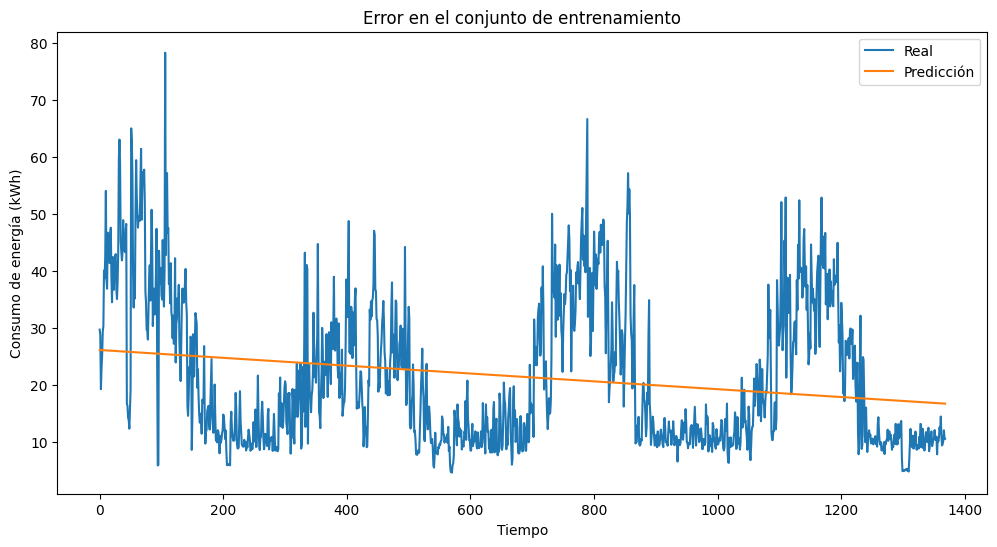

In [13]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

#Convirtiendo fechas a  datetime
df['date'] = pd.to_datetime(df['date'])

#Creando conjuntos de train y test
train = df[df['date'] <= '2020-02-29']
test = df[df['date'] >= '2020-03-01']

# Convertiendo fechas a valores numéricos
X_train = train['date'].map(pd.Timestamp.toordinal).values.reshape(-1, 1)
X_test = test['date'].map(pd.Timestamp.toordinal).values.reshape(-1, 1)

# Crear y entrenar pipeline
pipeline_trend = Pipeline([('linear', LinearRegression())])
pipeline_trend.fit(X_train, train['Energy_kWh'])

# Haciendo predicciones con el pipeline
pred_train = pipeline_trend.predict(X_train)
pred_test = pipeline_trend.predict(X_test)

# Evaluando metricas MAE en entrenamiento y prueba
print("MAE (train):", mean_absolute_error(train['Energy_kWh'], pred_train))
print("MAE (test):", mean_absolute_error(test['Energy_kWh'], pred_test))

# Graficando error
plt.figure(figsize=(12, 6))
plt.plot(train['Energy_kWh'], label='Real')
plt.plot(pred_train, label='Predicción')
plt.xlabel('Tiempo')
plt.ylabel('Consumo de energía (kWh)')
plt.title('Error en el conjunto de entrenamiento')
plt.legend()
plt.show()




R: en una instancia al ver el grafico se observa que no presenta un comportamiento lineal, por ende usar una regresión lineal no sirve en este caso, ademas de que el grafico se presenta una linealidad, por ende habria que usar un modelo no lineal que capture el comportamiento.

## 1.3 Un Consejo para Homero [6 puntos]

<center>
<img src ="https://media.tenor.com/sjbvGMLZiDkAAAAM/the-simpsons-homner-simpson.gif" width = 400 />

Homero al observar los resultados obtenidos, se mostró conforme y decidió no seguir averiguando al respecto. Usted, como buen amigo y utilizando sus recientes conocimientos en Forecast, le sugiere a Homero utilizar **Prophet**, una herramienta de modelado de series de tiempo que incluye descomposición de tendencias y estacionalidad, así como la capacidad de incorporar regresores adicionales. Usted le explica a Homero que Prophet es especialmente útil para realizar pronósticos cuando hay patrones estacionales y que podría mejorar los resultados que ha obtenido hasta ahora.

Homero, algo agotado debido al exhaustivo estudio que hizo para entender como funciona esta herramienta, le solicita ayuda para implementar Prophet y evaluar si puede obtener mejores resultados en sus predicciones de consumo energético.

Dado esto, Homero le pide que realice los siguientes pasos:

1. Instale y cargue Prophet a su entorno de trabajo. Luego renombre la variable temporal `date` por `ds` y la variable objetivo `Energy_kWh` por `y`, en los conjuntos de entrenamiento y de prueba. [1 punto]
2. Cree y ajuste el modelo Prophet con sus datos de entrenamiento. Luego realice prepare el dataset de predicciones con su set de prueba y realice las predicciones. `Nota:` Le puede ser útil este [Enlace](https://facebook.github.io/prophet/docs/quick_start.html#python-api) [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en todo el intervalo de tiempo. Analice sus resultados y responda: ¿Hay un comportamiento estacional en la serie? [1 punto]

In [14]:
!pip install prophet --upgrade --quiet
!pip install cmdstanpy --quiet


**Respuesta:**

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


MAE (train): 4.8174788644684785
MAE (test): 4.921090970247626


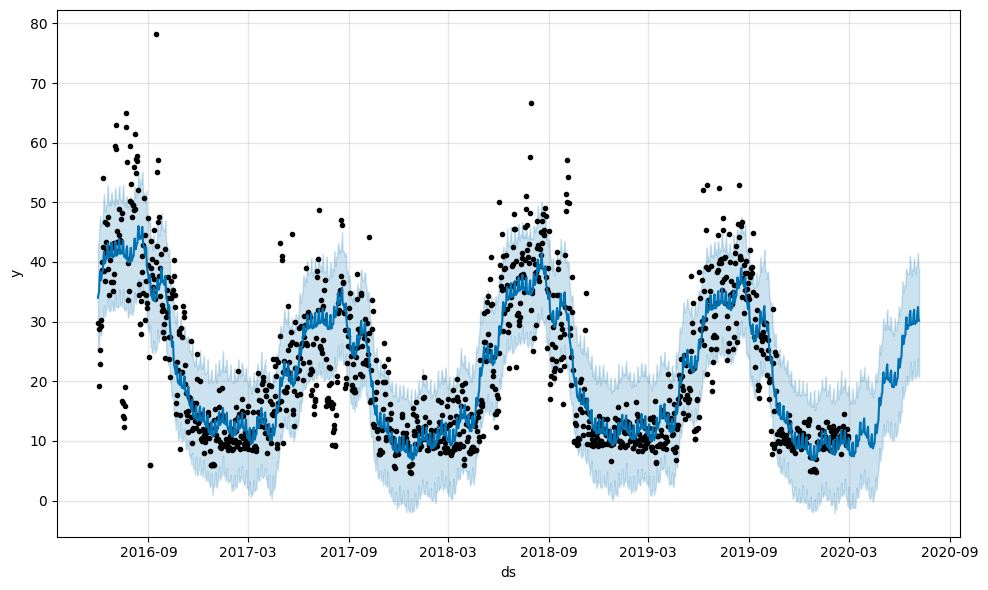

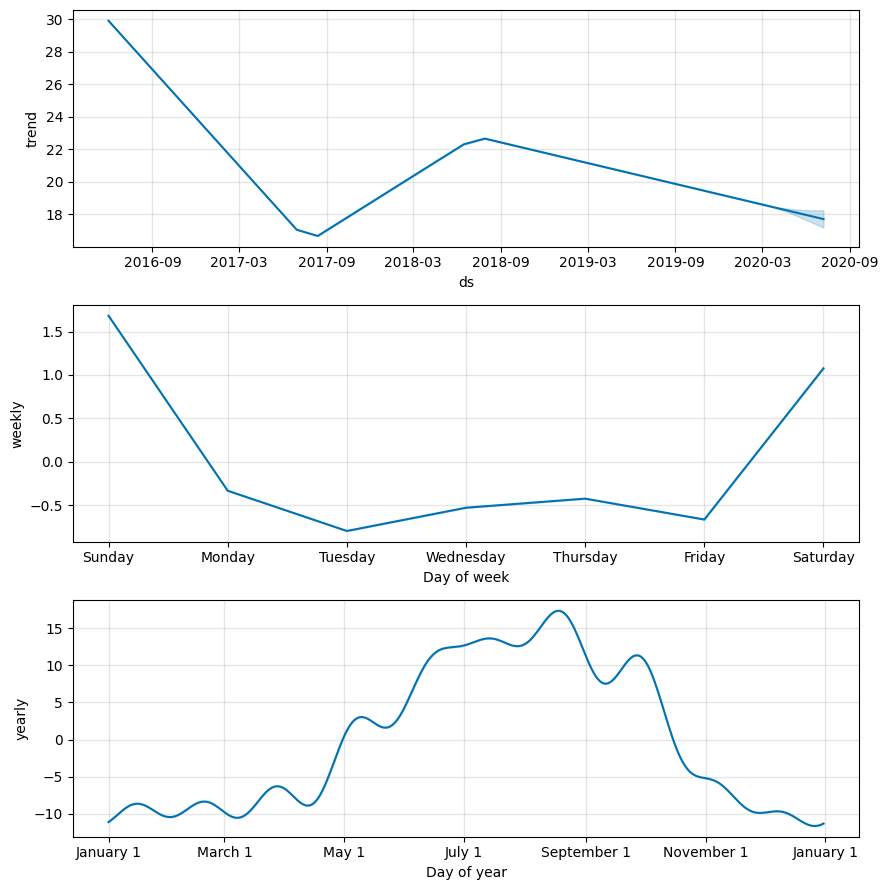

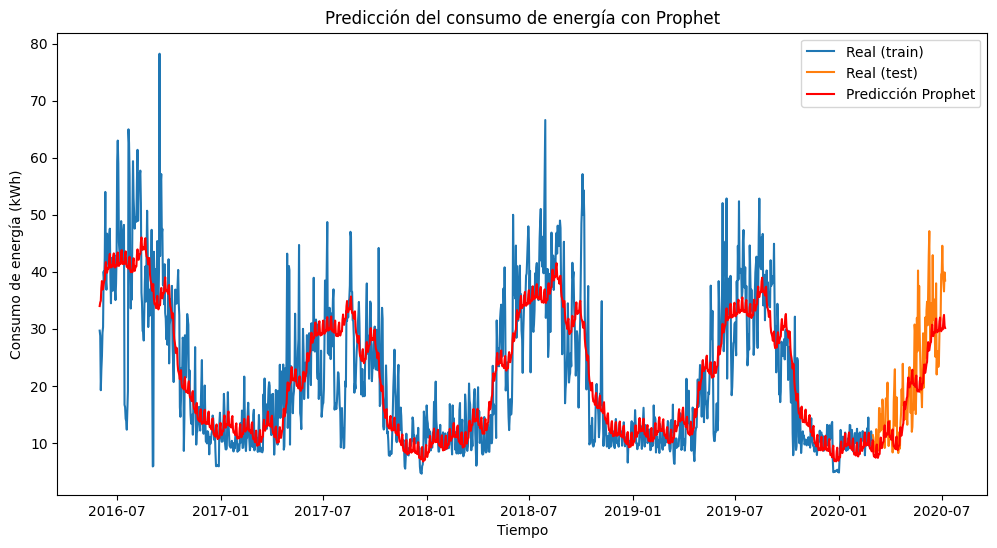

In [15]:
#CODIGO AQUI
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Preparando datos para usar Prophet
train_prophet = train.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})
test_prophet = test.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})

# Creando y ajustando modelo Prophet
model = Prophet()
model.fit(train_prophet)

# Generando predicciones para el futuro
future = model.make_future_dataframe(periods=len(test_prophet))
forecast = model.predict(future)

# Graficando pronóstico y componentes
model.plot(forecast)
model.plot_components(forecast)

# Calculando MAE para train y test
mae_train = mean_absolute_error(train_prophet['y'], forecast['yhat'][:len(train_prophet)])
mae_test = mean_absolute_error(test_prophet['y'], forecast['yhat'][len(train_prophet):])
print("MAE (train):", mae_train)
print("MAE (test):", mae_test)

# Graficando comparación real vs predicho
plt.figure(figsize=(12, 6))
plt.plot(train_prophet['ds'], train_prophet['y'], label='Real (train)')
plt.plot(test_prophet['ds'], test_prophet['y'], label='Real (test)')
plt.plot(forecast['ds'], forecast['yhat'], label='Predicción Prophet', color='red')
plt.xlabel('Tiempo')
plt.ylabel('Consumo de energía (kWh)')
plt.title('Predicción del consumo de energía con Prophet')
plt.legend()
plt.show()

R: como se dijo en la respuesta anterior se presenta una estacionaldad, aumentando el consumo electrico en los meses de mayo a noviembre, sobre todo los fines de semana y con MAE bajo en entrenamiento y prueba siendo un buen modelo en este caso.

## 1.4 Incluyendo Regresores [5 puntos]

<center>
<img src ="https://i.redd.it/64hwjftunjjd1.gif" width = 400 />

Con los nuevos resultados obtenidos del modelo Prophet, usted le aconseja a Homero que puede mejorar sus predicciones al incluir regresores en el modelo, es decir, variables adicionales que pueden influir en la variable objetivo, en este caso, el consumo energético. Homero encuentra que es una buena idea y va en busca de ayuda donde el Profesor Frink, un destacado Científico de Springfield. Para suerte de Homero, Frink tenía un estudio reciente que registra las condiciones climáticas en Springfield, en el mismo intervalo de tiempo en que Homero disponía de los datos de consumo eléctrico. Con esta nueva información, usted le recomienda a Homero que podrían utilizar esta información meteorológica proporcionada como variables exógenas al modelo.

Sin embargo, al no comprender bien la importancia de los regresores, Homero decide confiar en sus capacidades y le pide que, por favor, incluya estas variables en el modelo para evaluar su impacto en las predicciones.

Para ello, usted debe:
0. Seleccionar las variables exógenas a utilizar del archivo `datos_frink.csv`. Añada estas variables a sus conjuntos de entrenamiento y prueba mediante `merge`. [0 puntos]
1. Cree el modelo Prophet e incluya los regresores (variables exógenas) al modelo. Luego realice el entrenamiento. **Hint**: Utilice el método `.add_regressor()`. Mas información en el siguiente [Enlace](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#additional-regressors). [2 puntos]
2. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
3. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. Analice sus resultados. [1 punto]
4. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y de prueba. ¿Hay un comportamiento estacional en la serie? ¿Influyen estas variables en el comportamiento del consumo energético en el hogar de Homero? [1 punto]

Los datos del dataset de Frink son los siguientes:

* **date**: Fecha de medición.
* **Temp_max**: Temperatura máxima registrada durante el día (en °F).
* **Temp_avg**: Temperatura promedio registrada durante el día (en °F).
* **Temp_min**: Temperatura mínima registrada durante el día (en °F).
* **Dew_max**: Punto de rocío máximo registrado durante el día (en °F).
* **Dew_avg**: Punto de rocío promedio registrado durante el día (en °F).
* **Dew_min**: Punto de rocío mínimo registrado durante el día (en °F).
* **Hum_max**: Humedad máxima registrada durante el día (en porcentaje).
* **Hum_avg**: Humedad promedio registrada durante el día (en porcentaje).
* **Hum_min**: Humedad mínima registrada durante el día (en porcentaje).
* **Wind_max**: Velocidad máxima del viento registrada durante el día (en millas por hora, mph).
* **Wind_avg**: Velocidad promedio del viento registrada durante el día (en millas por hora, mph).
* **Wind_min**: Velocidad mínima del viento registrada durante el día (en millas por hora, mph).
* **Press_max**: Presión atmosférica máxima registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_avg**: Presión atmosférica promedio registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_min**: Presión atmosférica mínima registrada durante el día (en pulgadas de mercurio, Hg).

**Respuesta:**

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


MAE (train): 4.8174788644684785
MAE (test): 4.921090970247626


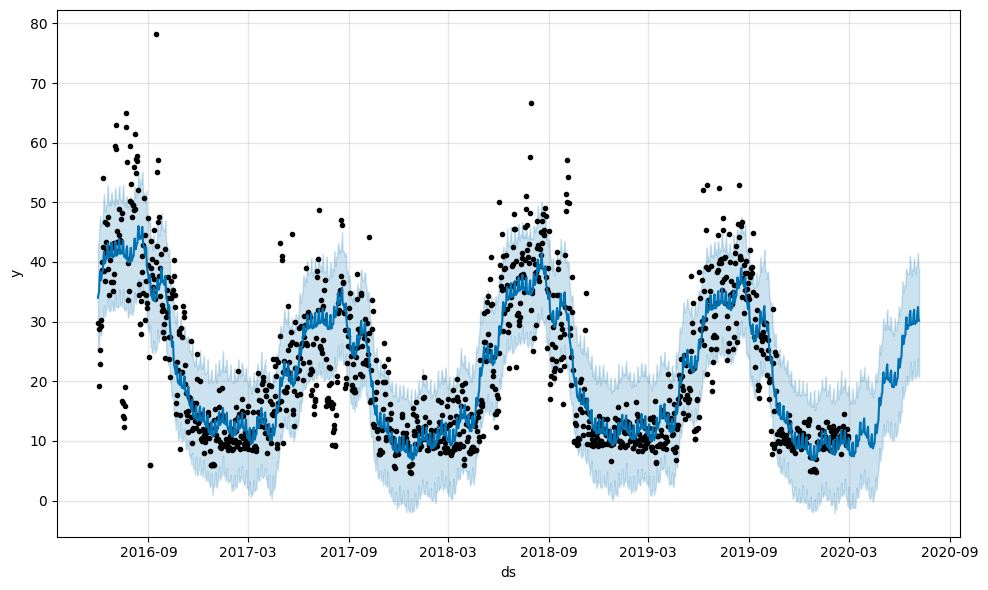

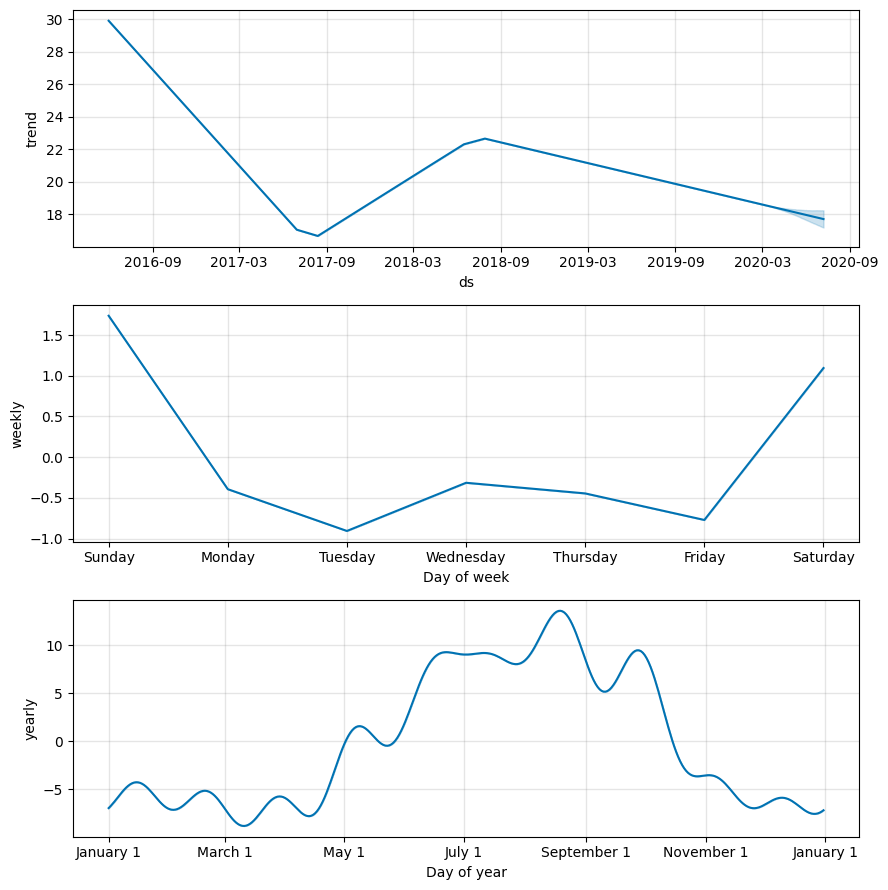

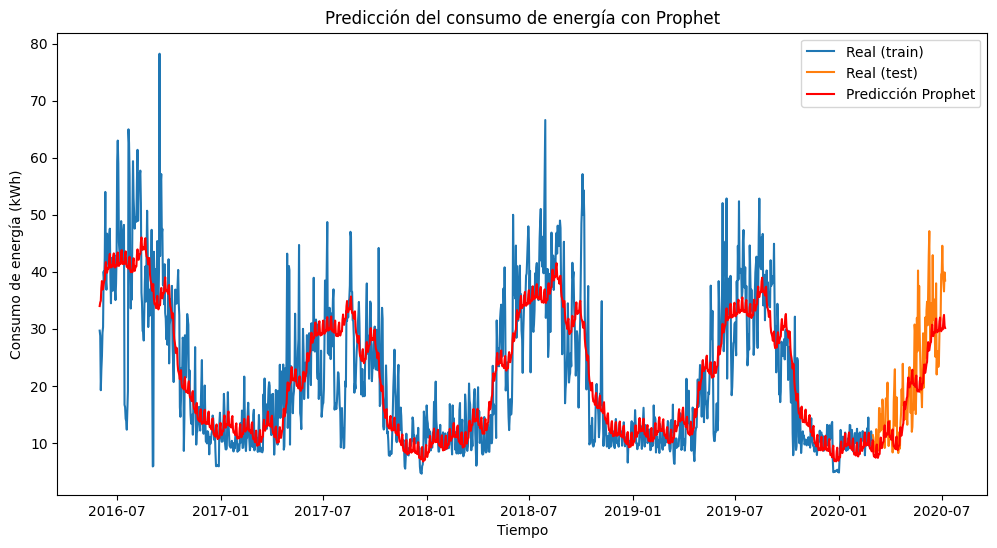

In [16]:
#CODIGO AQUI
#leyendo los datos datos_frink.csv
df2=pd.read_csv("/content/drive/MyDrive/homero_cervesa/datos_frink.csv")
#añadiendo variables de df2 al conjunto de entrenamiento y de prueba
df2 = df2.rename(columns={'date': 'ds'})
# Asegurando tipo datetime en todas las columnas 'ds' de los dataframe
train_prophet['ds'] = pd.to_datetime(train_prophet['ds'])
test_prophet['ds'] = pd.to_datetime(test_prophet['ds'])
df2['ds'] = pd.to_datetime(df2['ds'])
train_prophet = train_prophet.merge(df2, on='ds', how='left')
test_prophet = test_prophet.merge(df2, on='ds', how='left')

# Creando modelo con regresores externos
model = Prophet()
model.add_regressor('Temp_max')
model.add_regressor('Temp_avg')
model.add_regressor('Temp_min')
model.add_regressor('Dew_max')
model.add_regressor('Dew_avg')
model.add_regressor('Dew_min')
model.add_regressor('Hum_max')
model.add_regressor('Hum_avg')
model.add_regressor('Hum_min')
model.add_regressor('Wind_max')
model.add_regressor('Wind_avg')
model.add_regressor('Wind_min')
model.add_regressor('Press_max')
model.add_regressor('Press_avg')
model.add_regressor('Press_min')

# Ajustando el modelo
model.fit(train_prophet)

# Graficando pronóstico y componentes
model.plot(forecast)
model.plot_components(forecast)

# Calculando MAE para train y test
mae_train = mean_absolute_error(train_prophet['y'], forecast['yhat'][:len(train_prophet)])
mae_test = mean_absolute_error(test_prophet['y'], forecast['yhat'][len(train_prophet):])
print("MAE (train):", mae_train)
print("MAE (test):", mae_test)

# Graficando comparación real vs predicho
plt.figure(figsize=(12, 6))
plt.plot(train_prophet['ds'], train_prophet['y'], label='Real (train)')
plt.plot(test_prophet['ds'], test_prophet['y'], label='Real (test)')
plt.plot(forecast['ds'], forecast['yhat'], label='Predicción Prophet', color='red')
plt.xlabel('Tiempo')
plt.ylabel('Consumo de energía (kWh)')
plt.title('Predicción del consumo de energía con Prophet')
plt.legend()
plt.show()




R: Se evidencia un comportamiento estacional en la serie, pero las nuevas variables no modificaron mucho el mae en ambos conjuntos, pero la predicción en los gráficos se ajusta mejor en este gráfico que en le anterior, lo que hace que estas variables mejoren ligeramente el modelo.


## 1.5 Aplicando Lags [7 puntos]

<center>
<img src ="https://i.gifer.com/J45h.gif" width = 400 />

Homero, satisfecho con los resultados obtenidos, cree que aún puede mejorar el rendimiento del modelo incorporando lags de las variables exógenas. Se le ocurre que, al incluir estos lags, podría identificar cómo los valores pasados de las variables influyen en la evolución de la variable objetivo. Con esta idea en mente, Homero solicita su ayuda para encontrar y aplicar los lags adecuados a las variables exógenas de manera efectiva.

Para ello, a usted se le pide que:

1. Calcule la `Autocorrelación Parcial` de las variables exógenas `avg` que usted haya considerado. Por ejemplo: `Temp_avg, Dew_avg, etc`. Luego determine la cantidad de rezagos (lags) que se va a aplicar a cada una de las variables. Justifique. [1 punto]

2. Aplique los lags determinados en el paso anterior e incluyalos como variables en los conjuntos train y test. [1 punto]

3. Impute los valores nulos de los nuevos atributos lags mediante la media de cada variable. [1 punto]

4. Cree y entrene el modelo Prophet e incluya las variables exógenas y adicionalmente sus respectivos lags al modelo. [1 punto]

5. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
6. Calcule el `MAE` de la predicción en el conjunto de prueba y en el de entrenamiento. Analice sus resultados. [1 punto]
7. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y en el de prueba. ¿Hay un comportamiento estacional en la serie? ¿Como afecta la inclusión de los lags en el desempeño del modelo? [1 punto]


**Respuesta:**

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


MAE (train): 4.743807812634434
MAE (test): 4.602129396111108


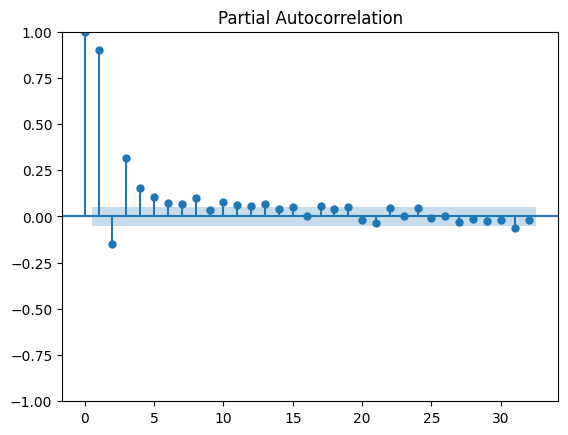

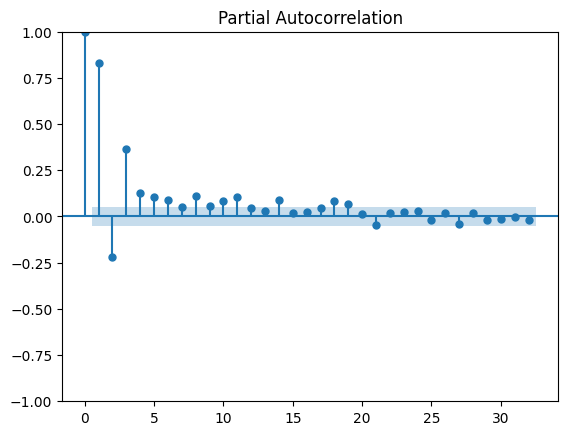

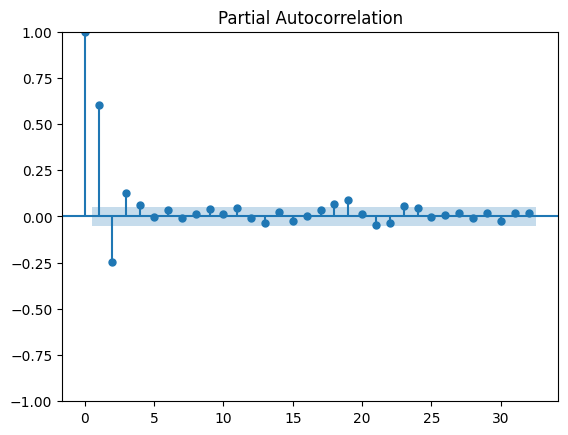

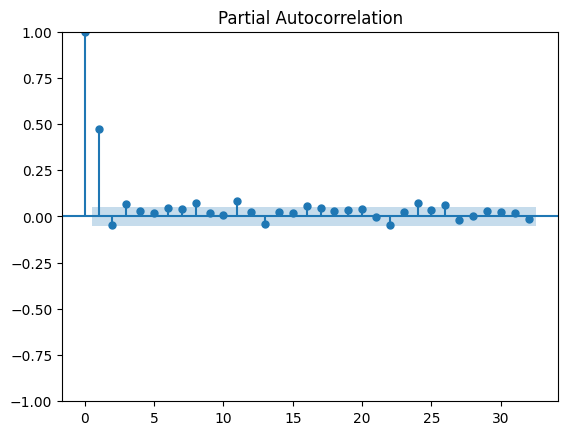

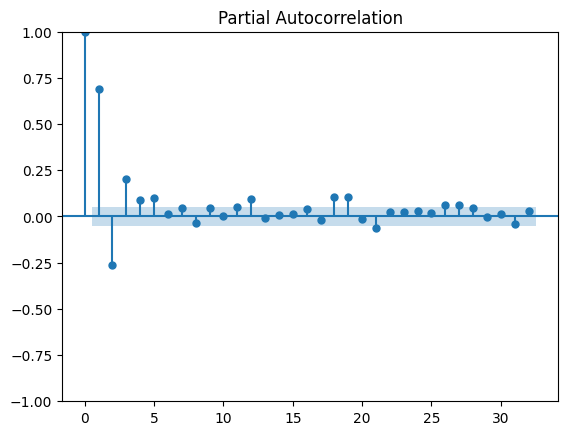

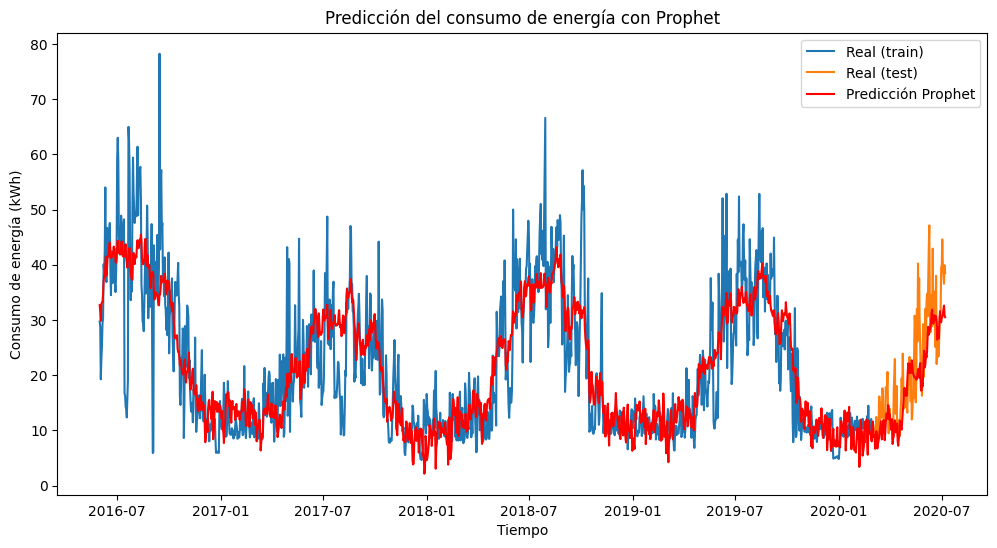

In [17]:
#CODIGO AQUI
from statsmodels.graphics.tsaplots import plot_pacf
#calculando la autocorreación parcial de las variables exogenas Temp_avg
plot_pacf(train_prophet['Temp_avg'])
plot_pacf(train_prophet['Dew_avg'])
plot_pacf(train_prophet['Hum_avg'])
plot_pacf(train_prophet['Wind_avg'])
plot_pacf(train_prophet['Press_avg'])


# Rezagos para Temp_avg
train_prophet['Temp_avg_lag1'] = train_prophet['Temp_avg'].shift(1)
train_prophet['Temp_avg_lag2'] = train_prophet['Temp_avg'].shift(2)

# Rezagos para Dew_avg
train_prophet['Dew_avg_lag1'] = train_prophet['Dew_avg'].shift(1)
train_prophet['Dew_avg_lag2'] = train_prophet['Dew_avg'].shift(2)

# Rezagos para Hum_avg
train_prophet['Hum_avg_lag1'] = train_prophet['Hum_avg'].shift(1)
train_prophet['Hum_avg_lag2'] = train_prophet['Hum_avg'].shift(2)

# Rezagos para Wind_avg
train_prophet['Wind_avg_lag1'] = train_prophet['Wind_avg'].shift(1)

# Rezagos para Press_avg
train_prophet['Press_avg_lag1'] = train_prophet['Press_avg'].shift(1)

#calculando medianas de las variables para reemplazar datos convertidos en valores omitidos
train_prophet['Temp_avg_lag1'] = train_prophet['Temp_avg_lag1'].fillna(train_prophet['Temp_avg_lag1'].median())
train_prophet['Temp_avg_lag2'] = train_prophet['Temp_avg_lag2'].fillna(train_prophet['Temp_avg_lag2'].median())

train_prophet['Dew_avg_lag1'] = train_prophet['Dew_avg_lag1'].fillna(train_prophet['Dew_avg_lag1'].median())
train_prophet['Dew_avg_lag2'] = train_prophet['Dew_avg_lag2'].fillna(train_prophet['Dew_avg_lag2'].median())

train_prophet['Hum_avg_lag1'] = train_prophet['Hum_avg_lag1'].fillna(train_prophet['Hum_avg_lag1'].median())
train_prophet['Hum_avg_lag2'] = train_prophet['Hum_avg_lag2'].fillna(train_prophet['Hum_avg_lag2'].median())

train_prophet['Wind_avg_lag1'] = train_prophet['Wind_avg_lag1'].fillna(train_prophet['Wind_avg_lag1'].median())

train_prophet['Press_avg_lag1'] = train_prophet['Press_avg_lag1'].fillna(train_prophet['Press_avg_lag1'].median())

#introduciendo rezagos en modelo prophet
model = Prophet()
model.add_regressor('Temp_avg_lag1')
model.add_regressor('Temp_avg_lag2')
model.add_regressor('Dew_avg_lag1')
model.add_regressor('Dew_avg_lag2')
model.add_regressor('Hum_avg_lag1')
model.add_regressor('Hum_avg_lag2')
model.add_regressor('Wind_avg_lag1')
model.add_regressor('Press_avg_lag1')



#Entrenando modelo
model.fit(train_prophet)

# Creando conjunto combinado  para predecir
future = pd.concat([train_prophet, test_prophet]).reset_index(drop=True)

# Creando los mismos rezagos para el conjunto futuro
for var in ['Temp_avg', 'Dew_avg', 'Hum_avg', 'Wind_avg', 'Press_avg']:
    future[f'{var}_lag1'] = future[var].shift(1)
    if var != 'Wind_avg' and var != 'Press_avg':
        future[f'{var}_lag2'] = future[var].shift(2)

# Imputando nulos nuevamente con la mediana
for col in [
    'Temp_avg_lag1', 'Temp_avg_lag2', 'Dew_avg_lag1', 'Dew_avg_lag2',
    'Hum_avg_lag1', 'Hum_avg_lag2', 'Wind_avg_lag1', 'Press_avg_lag1'
]:
    future[col] = future[col].fillna(future[col].median())

#Generando predicciones
forecast = model.predict(future)

#Separando predicciones para train y test
n_train = len(train_prophet)
n_test = len(test_prophet)
forecast_train = forecast.iloc[:n_train]
forecast_test = forecast.iloc[n_train:n_train + n_test]

# Calculando MAE
mae_train = mean_absolute_error(train_prophet['y'], forecast_train['yhat'])
mae_test = mean_absolute_error(test_prophet['y'], forecast_test['yhat'])
print("MAE (train):", mae_train)
print("MAE (test):", mae_test)

# Graficando comparación real vs predicho
plt.figure(figsize=(12, 6))
plt.plot(train_prophet['ds'], train_prophet['y'], label='Real (train)')
plt.plot(test_prophet['ds'], test_prophet['y'], label='Real (test)')
plt.plot(forecast['ds'], forecast['yhat'], label='Predicción Prophet', color='red')
plt.xlabel('Tiempo')
plt.ylabel('Consumo de energía (kWh)')
plt.title('Predicción del consumo de energía con Prophet')
plt.legend()
plt.show()




R: los lag mejoran los MAE tanto en entrenamiento como en prueba, mostrando que las variables del cientifico de los simpsons mejoran el modelo, solo faltaba la inclusión de lag en las variables para este resultado, en una serie que presenta estacionalidad. se escogio 2 lags en las variables 'Temp_avg', 'Dew_avg' y 'Hum_avg' al presentar dos cortes abruptos; Mientra 'Wind_avg' y 'Press_avg' se escoge uno debido a que solo se presenta un lag en la Autocorrelación Parcial.

## 1.6 Optimizando Prophet [6 puntos]

<center>
<img src ="https://i.gifer.com/BKlg.gif" width = 500 />

Homero, contento con sus resultados, decide compartir su trabajo en LinkedIn. Sin embargo, justo antes de realizar la publicación, su hija Lisa Simpson le comenta que su modelo podría mejorar aún más mediante la optimización de hiperparámetros. Aunque Homero no entiende muy bien a qué se refiere Lisa, decide confiar en su conocimiento y le pide ayuda para implementar la optimización.

Lisa le prepara una función llamada optimize_prophet, que recibe como entrada el registro histórico, los datos a predecir (futuros), el nombre de las variables exógenas y una grilla de hiperparámetros que se desea modificar.

Después de varios intentos, Homero no logra utilizar la función de Lisa y, desesperado por publicar sus resultados en internet, se acerca a usted en busca de ayuda.

Para ello, usted decide realizar los siguientes pasos:

1. Crear una grilla donde se modifiquen los siguientes hiperparámetros: `changepoint_prior_scale`, `seasonality_prior_scale`, `seasonality_mode`, `changepoint_range` y encuentre los hiperparámetros que optimicen el `MAE`. `Nota:` Utilice la función `optimize_prophet()` dada en el enunciado. [1 punto]
2. Crear y entrenar un modelo Prophet utilizando los mejores parámetros encontrados, incluyendo regresores (variables exógenas). [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y en el de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en ambos conjuntos. Analice sus resultados. [1 punto]


In [18]:
#NO MODIFICAR ESTA CELDA

import itertools
import numpy as np
import pandas as pd
from tqdm import tqdm
import logging

# Silenciar el logging de Prophet
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)


def optimize_prophet(df, df_to_pred, features, param_grid ):
  '''
  Función que recibe como entrada:
  -df: data entrenamiento.
  -df_to_pred: data a predecir (test).
  -features: lista de variables exógenas.
  -param_grid: grilla de hiperparámetros.

  Retorna:
  -tuning_results: Dataframe con resultados de la optimización.
  -best_params: Diccionario de mejores parámetros encontrados.
  '''

  # Generate all combinations of parameters
  all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
  MAEs = []  # Store the MAEs for each params here

  # Use tqdm to add a progress bar to the parameter tuning loop
  for params in tqdm(all_params, desc="Tuning Prophet parameters"):
      m = Prophet(**params)  # Fit model with given params
      for feature in features:
          m.add_regressor(feature)
      m.fit(df)

      # Prepare future dataframe
      df_prop = m.make_future_dataframe(periods=len(df_to_pred))
      df_feat = pd.concat([df[features], df_to_pred[features]]).reset_index(drop=True)
      df_prop[features] = df_feat[features]

      # Make predictions
      forecast = m.predict(df_prop)
      forecast_pred = forecast[forecast['ds'].isin(df_to_pred['ds'])].reset_index(drop=True)

      # Calculate MAE for the predictions
      mae_pred = mean_absolute_error(df_to_pred['y'], forecast_pred['yhat'])
      MAEs.append(mae_pred)

  # Find the best parameters
  tuning_results = pd.DataFrame(all_params)
  tuning_results['MAEs'] = MAEs
  tuning_results = tuning_results.sort_values(by='MAEs', ascending=True)
  best_params = all_params[np.argmin(MAEs)]
  return tuning_results, best_params

**Respuesta:**

Tuning Prophet parameters: 100%|██████████| 72/72 [01:01<00:00,  1.18it/s]

Mejores hiperparámetros encontrados:
{'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 5.0, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.95}
Top 5 combinaciones por MAE:


,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,changepoint_range,MAEs
29,0.01,5.0,multiplicative,0.95,4.187676
23,0.01,1.0,multiplicative,0.95,4.193211
21,0.01,1.0,multiplicative,0.80,4.194023
28,0.01,5.0,multiplicative,0.90,4.201131
31,0.01,10.0,additive,0.90,4.205370


MAE (Entrenamiento): 4.8434
 MAE (Prueba): 4.1877


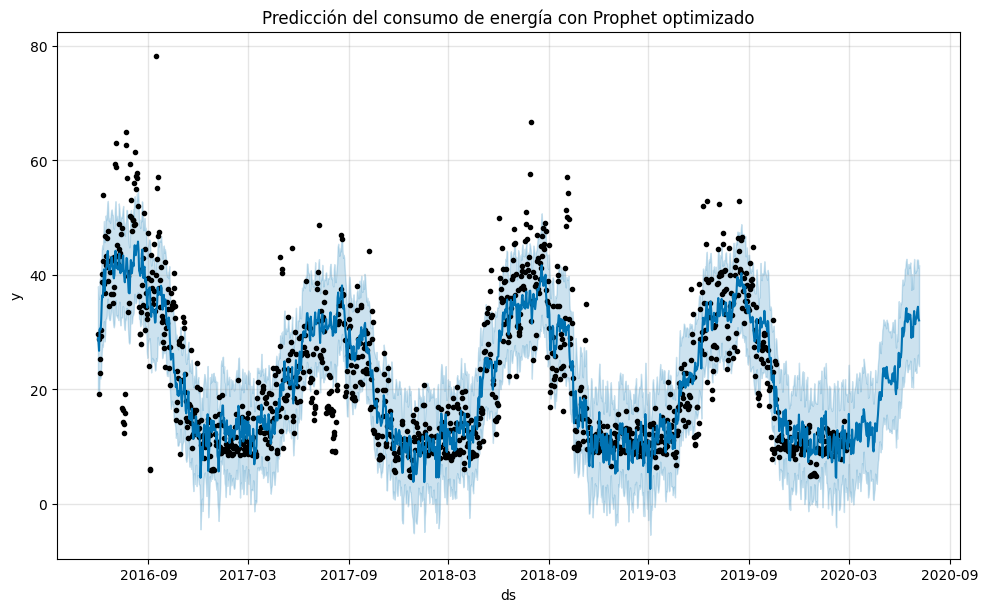

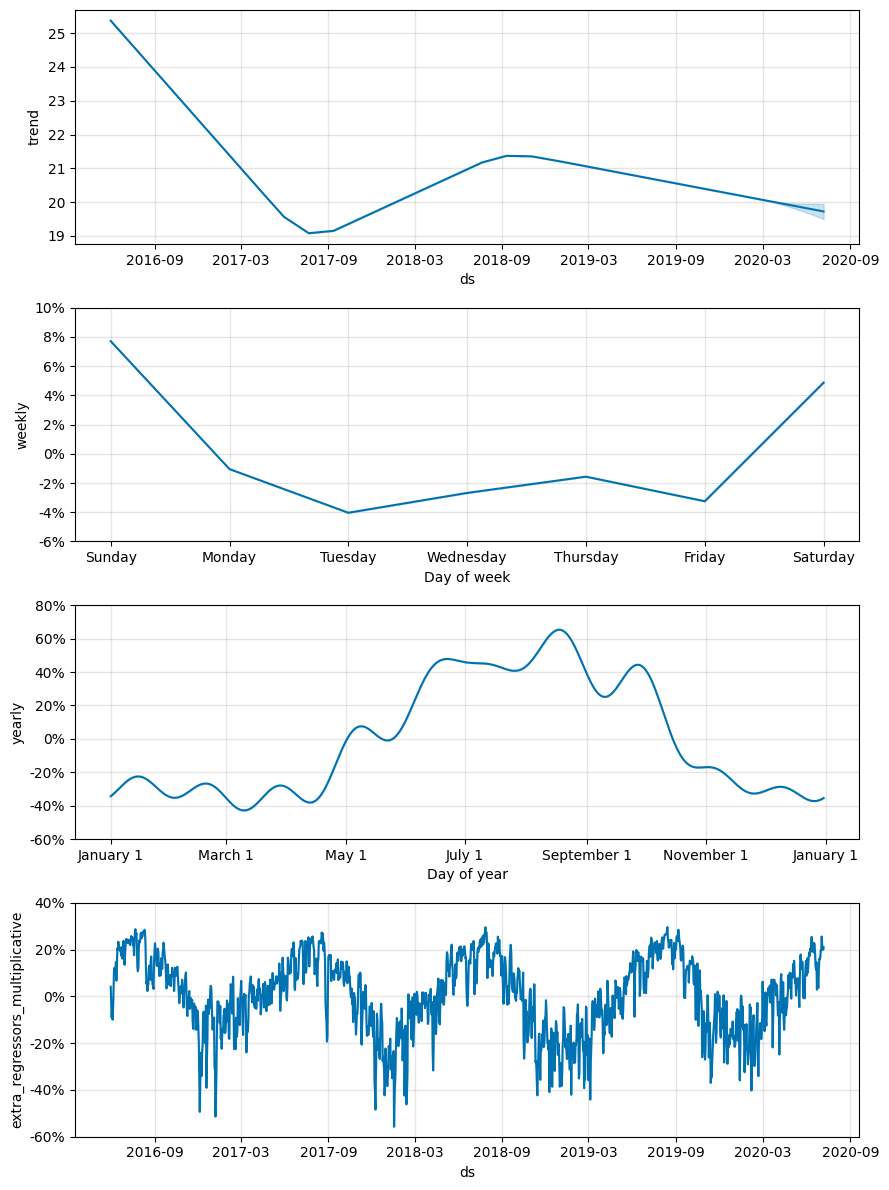

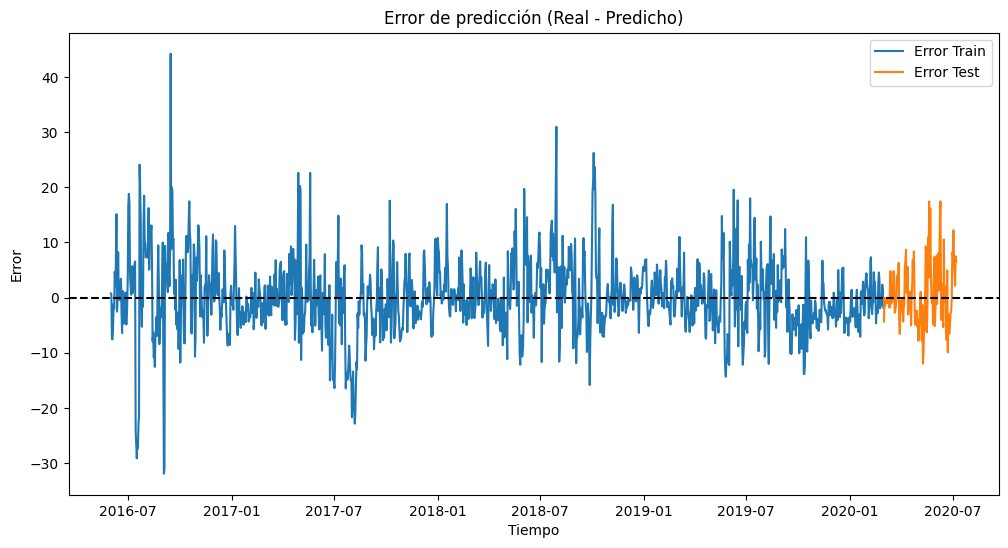

In [19]:
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# Creando los rezagos e imputar
for var in ['Temp_avg', 'Dew_avg', 'Hum_avg', 'Wind_avg', 'Press_avg']:
    train_prophet[f'{var}_lag1'] = train_prophet[var].shift(1)
    if var not in ['Wind_avg', 'Press_avg']:
        train_prophet[f'{var}_lag2'] = train_prophet[var].shift(2)

# Imputando valores nulos para entrenamiento
for col in [
    'Temp_avg_lag1', 'Temp_avg_lag2',
    'Dew_avg_lag1', 'Dew_avg_lag2',
    'Hum_avg_lag1', 'Hum_avg_lag2',
    'Wind_avg_lag1', 'Press_avg_lag1'
]:
    train_prophet[col] = train_prophet[col].fillna(train_prophet[col].median())

# Imputando valores nulos para prueba
for var in ['Temp_avg', 'Dew_avg', 'Hum_avg', 'Wind_avg', 'Press_avg']:
    test_prophet[f'{var}_lag1'] = test_prophet[var].shift(1)
    if var not in ['Wind_avg', 'Press_avg']:
        test_prophet[f'{var}_lag2'] = test_prophet[var].shift(2)

for col in [
    'Temp_avg_lag1', 'Temp_avg_lag2',
    'Dew_avg_lag1', 'Dew_avg_lag2',
    'Hum_avg_lag1', 'Hum_avg_lag2',
    'Wind_avg_lag1', 'Press_avg_lag1'
]:
    test_prophet[col] = test_prophet[col].fillna(test_prophet[col].median())

# Creando grilla de hiperparámetros
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [1.0, 5.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative'],
    'changepoint_range': [0.8, 0.9, 0.95]
}

features = [
    'Temp_avg_lag1', 'Temp_avg_lag2',
    'Dew_avg_lag1', 'Dew_avg_lag2',
    'Hum_avg_lag1', 'Hum_avg_lag2',
    'Wind_avg_lag1', 'Press_avg_lag1'
]

# Optimizando los hiperparámetros
tuning_results, best_params = optimize_prophet(train_prophet, test_prophet, features, param_grid)

print("Mejores hiperparámetros encontrados:")
print(best_params)

print("Top 5 combinaciones por MAE:")
display(tuning_results.head())

# Creando y entrenando modelo Prophet con mejores hiperparámetros
best_model = Prophet(**best_params)
for feature in features:
    best_model.add_regressor(feature)

best_model.fit(train_prophet)

# Creando conjunto combinado  para predecir
future = pd.concat([train_prophet, test_prophet]).reset_index(drop=True)
forecast = best_model.predict(future)


n_train = len(train_prophet)
n_test = len(test_prophet)

#separando en conjunto de entrenamiento y prueba
forecast_train = forecast.iloc[:n_train]
forecast_test = forecast.iloc[n_train:n_train + n_test]

#  Calculando MAE
mae_train = mean_absolute_error(train_prophet['y'], forecast_train['yhat'])
mae_test = mean_absolute_error(test_prophet['y'], forecast_test['yhat'])

print(f"MAE (Entrenamiento): {mae_train:.4f}")
print(f" MAE (Prueba): {mae_test:.4f}")


# Graficando pronóstico y componentes
best_model.plot(forecast)
plt.title("Predicción del consumo de energía con Prophet optimizado")
plt.show()

best_model.plot_components(forecast)
plt.show()

# Alineando por fechas
forecast_train = forecast[forecast['ds'].isin(train_prophet['ds'])].reset_index(drop=True)
forecast_test = forecast[forecast['ds'].isin(test_prophet['ds'])].reset_index(drop=True)

# Calculando errores
train_error = train_prophet['y'].values - forecast_train['yhat'].values
test_error = test_prophet['y'].values - forecast_test['yhat'].values

#generando grafico
plt.figure(figsize=(12,6))
plt.plot(train_prophet['ds'], train_error, label='Error Train')
plt.plot(test_prophet['ds'], test_error, label='Error Test')
plt.axhline(0, color='black', linestyle='--')
plt.title("Error de predicción (Real - Predicho)")
plt.xlabel("Tiempo")
plt.ylabel("Error")
plt.legend()
plt.show()




R: Se muestra el mejor MAE de toda la P1, se evidencia una temporalidad y se concluye que este es el mejor modelo de toda la P1.

# **2. Sistemas de Recomendación (30 puntos)**

## Homero contra la Prohibición

<center>
<img src ="https://i.ytimg.com/vi/rMSXXuhZjYY/maxresdefault.jpg" width = 500 />

En Springfield, el caos estalló cuando las autoridades prohibieron el alcohol. Pero como siempre, donde otros ven problemas, Homero Simpson ve oportunidades. Decidido a mantener las fiestas vivas, se convirtió en el Barón de la Cerveza en un abrir y cerrar de ojos. Con la ayuda de su buen amigo Moe el cantinero, Homero obtuvo un valioso dataset llamado `cervezas.csv`, que contiene valoraciones de los ciudadanos de Springfield sobre distintas cervezas. Homero quiere asegurarse de ofrecer las cervezas más apreciadas para mantener a su clientela oculta y feliz, mientras eludía la mirada del estricto Elio Pez. Por ende, Homero lo contacta para solicitar de su ayuda en esta nueva labor.

El dataset contiene los siguientes atributos:

  * userId: Identificador de los ciudadanos/usuarios
  * beerId: Identificador único de cada cerveza
  * rating: Evaluación otorgada por el ciudadano a la cerveza, en un rango de 1.0 a 5.0.
  * beerName: Nombre de la cerveza
  * beerStyle: Tipo de Cerveza.



In [20]:
!pip install scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2555151 sha256=dfeaceec18b917d730bc39230da56eac54471f1db48d600bbec832ef6158205b
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [15]:
# Librerias extras
from sklearn.preprocessing import LabelEncoder

from surprise import accuracy
from surprise.reader import Reader
from surprise.dataset import Dataset
from surprise.prediction_algorithms.knns import KNNBasic
from surprise.prediction_algorithms.matrix_factorization import SVD
from surprise.accuracy import mae
from surprise import NMF
from collections import defaultdict
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import pandas as pd
from copy import deepcopy
from matplotlib import pyplot as plt
import seaborn as sns

## Carga de los datos [0 puntos]

Cargue el dataset `cervezas.csv` y realice una breve exploración de los datos. ¿Hay valores nulos? ¿Cuantos cervezas se estan evaluando? ¿Cuantos ciudadanos participaron de esta evaluación?

In [13]:
#CODIGO AQUI
df3=pd.read_csv("cervezas.csv")

## 2.1 Caracterización Inicial [3 puntos]

Antes de entrenar nuestro sistema recomendador, es necesario caracterizar los datos disponibles y de esta manera tener un mejor entendimiento del problema a resolver. Para esto, se le pide lo siguiente:

1. Genere gráficos y/o estadística descriptiva con los datos. Utilice su análisis para responder las siguientes preguntas: [2 puntos]
  - ¿Cuantos *usuarios* hay en los datos? 706
  - ¿Cuantos *productos* hay en los datos?3747
  - ¿Cuantas *calificaciones* hay en los datos? 8
  - ¿Cuantas *calificaciones* faltantes hay en los datos? 0
  - ¿Cual es la media de las *calificaciones* entregadas por los usuarios? ¿Cómo cambia esto a través de los productos?  
2. Transforme los datos entregados a una matriz (usuario, producto) y muestre sus resultados. [1 punto]

In [5]:
#viendo si hay nulos
df3.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295059 entries, 0 to 295058
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     295059 non-null  int64  
 1   beerId     295059 non-null  int64  
 2   rating     295059 non-null  float64
 3   beerName   295059 non-null  object 
 4   beerStyle  295059 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 11.3+ MB


In [6]:
#viendo para ver cantidad de usuarios
a=df3.drop_duplicates(subset='userId', keep='first').reset_index(drop=True)
a.describe()

,userId,beerId,rating
count,706.000000,706.000000,706.000000
mean,3969.155807,16933.290368,3.699717
std,6150.677991,18982.143245,0.766164
min,1.000000,11.000000,1.000000
25%,310.000000,2040.250000,3.000000
50%,811.500000,6511.000000,4.000000
75%,4086.500000,30909.000000,4.000000
max,27681.000000,71969.000000,5.000000


In [7]:
#viendo cantidad de productos
df3.drop_duplicates(subset='beerId', keep='first').reset_index(drop=True)

,userId,beerId,rating,beerName,beerStyle
0,144,995,3.0,Mai Bock,Maibock / Helles Bock
1,63,58695,4.0,Hop In The Dark Cascadian Dark Ale,American Black Ale
2,147,4083,5.0,Stone Ruination IPA,American Double / Imperial IPA
3,4261,40310,3.0,Noël Des Géants,Herbed / Spiced Beer
4,140,1904,5.0,Sierra Nevada Celebration Ale,American IPA
...,...,...,...,...,...
3742,267,47589,4.5,Red,American Amber / Red Ale
3743,694,62792,2.0,Splinter Black,American Double / Imperial Stout
3744,718,18432,3.0,Wittekerke Rosé,Fruit / Vegetable Beer
3745,1503,4753,4.0,Hambleton Nightmare (Extra Stout Porter),English Porter


In [8]:
#viendo cantidad de notas distintas
df3.drop_duplicates(subset='rating', keep='first').reset_index(drop=True)

,userId,beerId,rating,beerName,beerStyle
0,144,995,3.0,Mai Bock,Maibock / Helles Bock
1,63,58695,4.0,Hop In The Dark Cascadian Dark Ale,American Black Ale
2,147,4083,5.0,Stone Ruination IPA,American Double / Imperial IPA
3,35,14309,3.5,Samuel Adams Chocolate Bock,Bock
4,393,2931,2.0,Two Druids Gruit Ale,Scottish Gruit / Ancient Herbed Ale
5,207,1696,4.5,Trappistes Rochefort 8,Dubbel
6,193,619,2.5,Boont ESB,Extra Special / Strong Bitter (ESB)
7,677,2213,1.0,Crazy Ed's Cave Creek Chili Beer,Chile Beer
8,35,71758,1.5,Samuel Adams Bonfire Rauchbier,Rauchbier


In [9]:
#viendo cantidad de notas
df3.dropna(subset=['rating']).reset_index(drop=True)

,userId,beerId,rating,beerName,beerStyle
0,144,995,3.0,Mai Bock,Maibock / Helles Bock
1,63,58695,4.0,Hop In The Dark Cascadian Dark Ale,American Black Ale
2,147,4083,5.0,Stone Ruination IPA,American Double / Imperial IPA
3,4261,40310,3.0,Noël Des Géants,Herbed / Spiced Beer
4,140,1904,5.0,Sierra Nevada Celebration Ale,American IPA
...,...,...,...,...,...
295054,863,45653,4.0,Consecration,American Wild Ale
295055,306,1341,4.0,Keystone Light,Light Lager
295056,8,8917,3.0,Drop Top Amber,American Amber / Red Ale
295057,35,102,3.0,Samuel Adams Octoberfest,Märzen / Oktoberfest


In [10]:
#viendo media de las notas
df3['rating'].describe()

count    295059.000000
mean          3.860367
std           0.702807
min           1.000000
25%           3.500000
50%           4.000000
75%           4.500000
max           5.000000
Name: rating, dtype: float64


Análisis de calificaciones por producto:

Gráfico 'distribucion_calificaciones_medias.png' guardado.


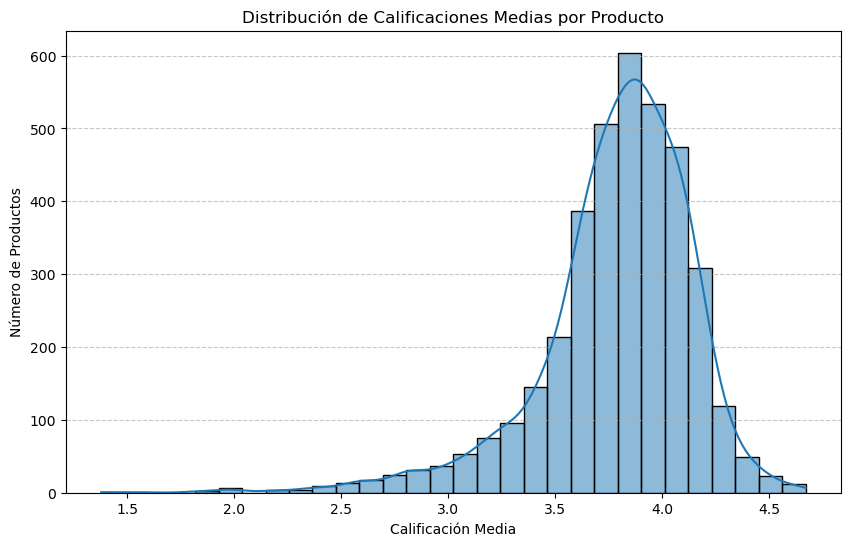

In [16]:
# Haciendo histograma de los productos
print("\nAnálisis de calificaciones por producto:")
media_por_producto = df3.groupby('beerId')['rating'].mean().sort_values(ascending=False)

# graficando histograma
plt.figure(figsize=(10, 6))
sns.histplot(media_por_producto.dropna(), kde=True, bins=30)
plt.title('Distribución de Calificaciones Medias por Producto')
plt.xlabel('Calificación Media')
plt.ylabel('Número de Productos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('distribucion_calificaciones_medias.png')
print("\nGráfico 'distribucion_calificaciones_medias.png' guardado.")


In [ ]:
#  Haciendo Matriz usuario, producto
print("  Transformación a Matriz Usuario-Producto ")

# Creando la matriz usuario-producto con filas a los  usuarios y  columnas los productos
matriz_usuario_producto = df3.pivot_table(
    index='userId',
    columns='beerId',
    values='rating'
)

print(f"Dimensiones de la matriz: (Usuarios, Productos) -> {matriz_usuario_producto.shape}")

# Mostrando una vista parcial de la matriz
print("\nMostrando las primeras 5 filas y 5 columnas de la matriz:")
print(matriz_usuario_producto.iloc[:5, :5].to_markdown(floatfmt=".1f"))

# Calculando proporción de celdas vacías
num_celdas_totales = matriz_usuario_producto.size
num_calificaciones_reales = matriz_usuario_producto.count().sum()
esparsidad = 1.0 - (num_calificaciones_reales / num_celdas_totales)

print(f"\nLa matriz tiene {num_celdas_totales:,} celdas en total.")
print(f"Solo {num_calificaciones_reales:,} celdas tienen una calificación.")
print(f" Esparsidad de la matriz: {esparsidad:.2%}")
print(f"(Esto significa que el {esparsidad:.2%} de la matriz está vacío o tiene NaN)")



--- 2. Transformación a Matriz Usuario-Producto ---
Dimensiones de la matriz: (Usuarios, Productos) -> (706, 3747)

Mostrando las primeras 5 filas y 5 columnas de la matriz:
|   userId |     5 |     6 |     7 |     9 |    10 |
|---------:|------:|------:|------:|------:|------:|
|        1 | nan   | nan   | nan   | nan   | nan   |
|        3 |   3.4 |   3.8 |   3.3 |   3.5 | nan   |
|        4 | nan   | nan   | nan   | nan   |   3.8 |
|        5 | nan   | nan   | nan   | nan   | nan   |
|        6 | nan   | nan   | nan   | nan   | nan   |

La matriz tiene 2,645,382 celdas en total.
Solo 3,747 celdas tienen una calificación.
 Esparsidad de la matriz: 99.86%
(Esto significa que el 99.86% de la matriz está vacío o tiene NaN)


El conjunto de datos contiene 706 usuarios y 3747 cervezas, con 295059 calificaciones y sin valores faltantes en la variable rating. La calificación promedio global es cercana a 3.86 y la distribución de las medias por producto se concentra entre 3.5 y 4.2, con pocos productos muy mal o muy bien evaluados. Lo que indica que los ciudadanos tienden a ser generosos al evaluar y que la escala se utiliza sobre todo en la parte alta, lo que dificulta separar de forma clara las cervezas realmente excepcionales de las que solo son aceptables

La matriz usuario producto obtenida mediante pivot tiene tamaño 706 por 3747 y presenta una esparsidad cercana al noventa por ciento, ya que solo una fracción pequeña de las posibles combinaciones usuario cerveza está observada. Esto indica que la mayoría de los usuarios ha probado pocas cervezas y que el sistema recomendador deberá trabajar con datos escasos y con información muy concentrada en los productos mas populares

## 2.2 Método Basado en Contenido [4 puntos]

<center>
<img src ="https://is1-ssl.mzstatic.com/image/thumb/WfNa_TwFpJoTWXQmU-BrbA/1200x675.jpg" width = 500 />

Como primera tarea, Homero le pide centrarse en las características de las cervezas y no en la interacción de los ciudadanos con esta. Adicionalmente, Homero le quiere regalar un pack de distintas cervezas a Carl en agradecimiento a su ayuda anterior, el cual se enteró que Carl tiene un `userId = 100`. Por ende, Homero le pide las siguientes acciones:

1. Cree un dataframe que contenga las características de las cervezas, excluyendo las evaluaciones de los ciudadanos. `Nota:` No considere valores duplicados. [1 punto]
2. Implemente el método Bag of Words para procesar la columna `beerStyle`. Para ello, transforme las palabras a minúsculas, elimine stopwords en inglés y filtre las palabras que aparezcan en 10 documentos como mínimo. Guarde su resultado como un DataFrame. [1 punto].
> `Nota:` Le puede ser útil esta [documentacion](https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) y el método `.get_feature_names_out()`.
3. Cree una función que imprima las top 5 cervezas similares a `Chocolate Porter`, utilizando como medida de similitud la similitud coseno. [1 punto]
4. Identifique la cerveza mejor evaluada por Carl (`userId = 100`) y obtenga las top 5 cervezas similares a esa cerveza. [1 punto]

**Respuesta:**

In [19]:
#CODIGO AQUI
# Creando dataframe de características de cervezas
print(" DataFrame de características de cervezas ")

# Excluyendo las evaluaciones
df_beers = df3[['beerId', 'beerName', 'beerStyle']].drop_duplicates(subset='beerId').reset_index(drop=True)

print(f"Se crearon {len(df_beers)} cervezas únicas.")
df_beers.head()

from sklearn.feature_extraction.text import CountVectorizer

# Bag of Words sobre beerStyle
print("Representación Bag of Words ")

vectorizer = CountVectorizer(
    lowercase=True,
    stop_words='english',
    min_df=10
)

X_bow = vectorizer.fit_transform(df_beers['beerStyle'].fillna(''))

# Conviritendo a DataFrame para inspección
df_bow = pd.DataFrame(X_bow.toarray(), columns=vectorizer.get_feature_names_out())

print(f"Dimensiones del Bag of Words: {df_bow.shape}")
df_bow.head()

from sklearn.metrics.pairwise import cosine_similarity

# Función para buscar cervezas similares
def cervezas_similares(nombre_cerveza, top_n=5):
    # Verificar si la cerveza existe
    if nombre_cerveza not in df_beers['beerName'].values:
        print(f"⚠️ '{nombre_cerveza}' no se encuentra en el catálogo.")
        return

    # Obteniendo índice de la cerveza
    idx = df_beers.index[df_beers['beerName'] == nombre_cerveza][0]

    # Calculando similitud coseno
    sims = cosine_similarity(df_bow.iloc[idx].values.reshape(1, -1), df_bow.values).flatten()

    # Ordenando de mayor a menor similitud (excluyendo la misma cerveza)
    similares_idx = sims.argsort()[::-1][1:top_n+1]

    # Mostrando resultados
    print(f" Cervezas similares a '{nombre_cerveza}':")
    for i, j in enumerate(similares_idx):
        print(f"{i+1}. {df_beers.loc[j, 'beerName']}  ({df_beers.loc[j, 'beerStyle']})  → similitud: {sims[j]:.3f}")
# Mejor cerveza evaluada segun Carl
print("Mejor cerveza evaluada segun Carl (userId=100) ")

carl_reviews = df3[df3['userId'] == 100]
best_carl = carl_reviews.loc[carl_reviews['rating'].idxmax()]

print(f"Cerveza mejor evaluada por Carl: {best_carl['beerName']} ({best_carl['rating']})")

# Buscando cervezas similares
cervezas_similares(best_carl['beerName'])


 DataFrame de características de cervezas 
Se crearon 3747 cervezas únicas.
Representación Bag of Words 
Dimensiones del Bag of Words: (3747, 95)
Mejor cerveza evaluada segun Carl (userId=100) 
Cerveza mejor evaluada por Carl: McNeill's Extra Special Bitter (4.5)
 Cervezas similares a 'McNeill's Extra Special Bitter':
1. S.O.B. (Special Old Bitter Ale)  (Extra Special / Strong Bitter (ESB))  → similitud: 1.000
2. Phoenixx Double ESB  (Extra Special / Strong Bitter (ESB))  → similitud: 1.000
3. XS Imperial Younger's Special Bitter  (Extra Special / Strong Bitter (ESB))  → similitud: 1.000
4. Redhook ESB  (Extra Special / Strong Bitter (ESB))  → similitud: 1.000
5. The Wise ESB  (Extra Special / Strong Bitter (ESB))  → similitud: 1.000


En los datos aparecen 3747 cervezas distintas y el Bag of Words genera 95 términos para describir los estilos lo que muestra que hay bastante variedad pero no tantos estilos realmente frecuentes. Para Carl su cerveza favorita es McNeill's Extra Special Bitter con nota 4.5 y las cinco recomendadas por el modelo son todas de estilo Extra Special o Strong Bitter. Las similitudes coseno son iguales a uno porque todas comparten exactamente el mismo estilo por lo que el recomendador está entregando cervezas muy coherentes con el gusto de Carl pero también poco diversas ya que solo varía la marca y no el tipo de cerveza. Esto refleja que un método basado solo en beerStyle funciona bien para encontrar cervezas del mismo perfil pero no capta otros matices del producto ni las preferencias más finas de los usuarios.

## 2.3 Filtros Colaborativos [16 puntos]

<center>
<img src ="https://i.makeagif.com/media/2-08-2016/McmGFQ.gif" width = 400 />

Después de consolidarse como el Barón de la Cerveza en Springfield, Homero Simpson decidió llevar su negocio clandestino a otro nivel. Al ser el único proveedor de alcohol en la ciudad, quiere asegurarse de que cada cerveza que elabora sea de la mejor calidad posible. Para lograrlo, planea usar las evaluaciones pasadas que los ciudadanos de Springfield han registrado sobre las distintas cervezas. Inspirado por los consejos de su amigo Moe, Homero se enteró de que puede implementar un sistema de recomendación basado en filtros colaborativos.

Ahora, Homero necesita de su ayuda para diseñar y elaborar distintos sistemas de filtros colaborativos que le permitan continuar con su reinado cervecero.

### 2.3.1 Filtros Colaborativos Basados en Memoria [8 puntos]

Para este tipo de filtros, Homero le pide lo siguiente:

1. Transforme el DataFrame de `pandas` a Dataset de `surprise`. `Hint`: Utilice solamente los identificadores de ciudadano, cerveza y rating. ¿Importa el orden? [1 punto]
2. Genere un conjunto de entrenamiento y uno de prueba, asegurando que el 30% de los datos sea destinado al conjunto de prueba. No olvide fijar una semilla para garantizar reproducibilidad. [1 punto]
3. Entrene un modelo de **KNN basado en usuarios** utilizando la `similitud coseno`. Luego realice predicciones en el conjunto de prueba. `Nota`: Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/knn_inspired.html) [2 puntos]
4. Calcule el MAE (Mean Absolute Error) de las predicciones realizadas por el modelo y muestre las predicciones en un DataFrame para su análisis. `Nota:` Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/accuracy.html#surprise.accuracy.mae) [2 puntos]
5. Repita los pasos 3 y 4 pero utilizando un modelo de **KNN basado en los productos**. [2 puntos]

**Respuesta:**

In [20]:
#CODIGO AQUI

import pandas as pd
from surprise import Reader, Dataset, KNNBasic, accuracy
from surprise.model_selection import train_test_split
from surprise.accuracy import mae


# cargando usuarios y cervesas sin duplicados
df_clean = df3.drop_duplicates(subset=['userId', 'beerId'], keep='first')

print(f"Datos limpios (sin duplicados): {len(df_clean)} filas")


#Definiendo el Reader con la escala de calificaciones
reader = Reader(rating_scale=(1, 5))

# Seleccionando solo las columnas necesarias EN EL ORDEN (Usuario, Producto, Calificación)
df_surprise = df_clean[['userId', 'beerId', 'rating']]

# Cargando el Dataset
data = Dataset.load_from_df(df_surprise, reader)


#  Dividiendo los datos (70% train, 30% test)
trainset, testset = train_test_split(data, test_size=0.30, random_state=42)


print("Modelo 1: KNN Basado en USUARIOS")

# Configurando el modelo de KNN
sim_options_user = {'name': 'cosine', 'user_based': True}
model_user = KNNBasic(sim_options=sim_options_user)

# Entrenando el modelo en el trainset
model_user.fit(trainset)

# Realizando predicciones en el testset
predictions_user = model_user.test(testset)

print("Paso 3: Modelo KNN-User entrenado y predicciones realizadas.")

# Calculando el MAE
mae_user = accuracy.mae(predictions_user)
print(f"Paso 4: MAE del modelo (User-Based): {mae_user:.4f}")

# Mostrando las predicciones en un DataFrame
df_pred_user = pd.DataFrame(
    [(pred.uid, pred.iid, pred.r_ui, pred.est, pred.details['was_impossible'])
     for pred in predictions_user],
    columns=['UserID', 'BeerID', 'Rating_Real', 'Rating_Predicho', 'Imposible']
)

print("Primeras 5 predicciones (User-Based):")
print(df_pred_user.head().to_markdown(index=False, floatfmt=".2f"))

print("\n--- Modelo 2: KNN Basado en PRODUCTOS ---")

#  Configurando el modelo Item-Based
sim_options_item = {'name': 'cosine', 'user_based': False}
model_item = KNNBasic(sim_options=sim_options_item)

# Entrenando el modelo
model_item.fit(trainset)

# Realizando predicciones
predictions_item = model_item.test(testset)
print(" Modelo KNN-Item entrenado y predicciones realizadas.")

# 4 (Repetido). Calcular el MAE
mae_item = accuracy.mae(predictions_item)
print(f"MAE del modelo (Item-Based): {mae_item:.4f}")

# Mostrar las predicciones en un DataFrame
df_pred_item = pd.DataFrame(
    [(pred.uid, pred.iid, pred.r_ui, pred.est, pred.details['was_impossible'])
     for pred in predictions_item],
    columns=['UserID', 'BeerID', 'Rating_Real', 'Rating_Predicho', 'Imposible']
)

print("\nPrimeras 5 predicciones (Item-Based):")
print(df_pred_item.head().to_markdown(index=False, floatfmt=".2f"))

Datos limpios (sin duplicados): 3747 filas
Modelo 1: KNN Basado en USUARIOS
Computing the cosine similarity matrix...
Done computing similarity matrix.
Paso 3: Modelo KNN-User entrenado y predicciones realizadas.
MAE:  0.5678
Paso 4: MAE del modelo (User-Based): 0.5678
Primeras 5 predicciones (User-Based):
|   UserID |   BeerID |   Rating_Real |   Rating_Predicho | Imposible   |
|---------:|---------:|--------------:|------------------:|:------------|
|      841 |     4718 |          2.00 |              3.79 | True        |
|      402 |     1192 |          4.50 |              3.79 | True        |
|     1675 |     4774 |          4.00 |              3.79 | True        |
|    17981 |    55278 |          3.50 |              3.79 | True        |
|       35 |    34833 |          4.50 |              3.79 | True        |

--- Modelo 2: KNN Basado en PRODUCTOS ---
Computing the cosine similarity matrix...
Done computing similarity matrix.
 Modelo KNN-Item entrenado y predicciones realizadas.
M

Los modelos KNN basados en usuarios y en productos entregan prácticamente el mismo desempeño con un MAE cercano a 0.57. En ambos casos muchas predicciones se acercan a un valor promedio cercano a 3.8 y aparecen varias observaciones marcadas como imposibles porque no existen vecinos con suficiente información para esos usuarios o cervezas. Esto muestra que en una matriz tan dispersa los métodos basados en memoria tienen dificultades para personalizar bien las recomendaciones y terminan aproximando al promedio global. En este contexto no hay una diferencia clara entre usar vecinos de usuarios o de productos ya que ambos explotan la misma información limitada y llegan a resultados muy similares

### 2.3.2 Filtros Colaborativos Basados en Modelo [8 puntos]

Ahora Homero le pide que cambie el enfoque del tipo de filtro colaborativo a uno basado en modelo. Por ende, Homero le pide lo siguiente:

1. Entrene un modelo `NMF` , asegurándose de fijar la semilla para reproducibilidad. Luego genere predicciones para el conjunto de prueba. [2 puntos]
2. Calcule el MAE de las predicciones obtenidas y muestre los resultados de las predicciones en un DataFrame para su analisis. [1 punto]
3. Entrene un modelo `SVD` sobre el conjunto de entrenamiento. Posteriormente, genere las predicciones para el conjunto de prueba. [2 puntos]
4. Calcule el MAE de las predicciones y muestre los resultados de las predicciones en un DataFrame. [1 punto]
5. Compare los resultados de ambos modelos y seleccione el mejor a su criterio. Justifique. [2 puntos]

**Respuesta**

In [ ]:
#CODIGO AQUI
#CODIGO AQUI
import pandas as pd
from surprise import Reader, Dataset, KNNBasic, NMF, SVD, accuracy
from surprise.model_selection import train_test_split
from surprise.accuracy import mae



# Limpiar duplicados 
df_clean = df3.drop_duplicates(subset=['userId', 'beerId'], keep='first')

# Cargar en surprise
reader = Reader(rating_scale=(1, 5))
df_surprise = df_clean[['userId', 'beerId', 'rating']]
data = Dataset.load_from_df(df_surprise, reader)

# Dividir en conjunto de entrenamiento y de prueba
trainset, testset = train_test_split(data, test_size=0.30, random_state=42)

print(f"Contexto recreado. Trainset: {trainset.n_ratings} ratings, Testset: {len(testset)} ratings.")
print("-" * 30)

# Entrenando NMF y Predecir
print("Modelo 3: NMF (Non-negative Matrix Factorization)")
model_nmf = NMF(random_state=42)
model_nmf.fit(trainset)

# Generando predicciones para el conjunto de prueba
predictions_nmf = model_nmf.test(testset)
print("Modelo NMF entrenado y predicciones realizadas.")

#  MAE y Análisis de NMF
print(" Cálculo de MAE y análisis de predicciones")
mae_nmf_value = accuracy.mae(predictions_nmf, verbose=True)

# Mostrando las predicciones en un DataFrame
df_pred_nmf = pd.DataFrame(
    [(pred.uid, pred.iid, pred.r_ui, pred.est, pred.details['was_impossible'])
     for pred in predictions_nmf],
    columns=['UserID', 'BeerID', 'Rating_Real', 'Rating_Predicho', 'Imposible']
)
print("\nPrimeras 5 predicciones (NMF):")
print(df_pred_nmf.head().to_markdown(index=False, floatfmt=".2f"))
print("-" * 30)

# Entrenando  SVD y Predecir ---
print("Modelo 4: SVD (Singular Value Decomposition) ")
# Fijamos la semilla (random_state=42) para reproducibilidad
model_svd = SVD(random_state=42)
model_svd.fit(trainset)

# Generar predicciones para el conjunto de prueba
predictions_svd = model_svd.test(testset)
print(" Modelo SVD entrenado y predicciones realizadas")

# MAE y Análisis de SVD 
print(" Cálculo de MAE y análisis de predicciones (SVD)")
# Usamos verbose=True para que imprima el MAE
mae_svd_value = accuracy.mae(predictions_svd, verbose=True)

# Mostrando las predicciones en un DataFrame
df_pred_svd = pd.DataFrame(
    [(pred.uid, pred.iid, pred.r_ui, pred.est, pred.details['was_impossible'])
     for pred in predictions_svd],
    columns=['UserID', 'BeerID', 'Rating_Real', 'Rating_Predicho', 'Imposible']
)
print("\nPrimeras 5 predicciones (SVD):")
print(df_pred_svd.head().to_markdown(index=False, floatfmt=".2f"))
print("-" * 30)


# Para una comparación justa, recalculamos rápidamente los MAE de los KNN
print(" RESUMEN DE COMPARACIÓN DE MODELOS ")

# Modelo KNN User
sim_options_user = {'name': 'cosine', 'user_based': True}
model_user = KNNBasic(sim_options=sim_options_user)
model_user.fit(trainset)
predictions_user = model_user.test(testset)
mae_user = accuracy.mae(predictions_user, verbose=False)
print(f"MAE (KNN User-Based): {mae_user:.4f}")

# Modelo KNN Item (
sim_options_item = {'name': 'cosine', 'user_based': False}
model_item = KNNBasic(sim_options=sim_options_item)
model_item.fit(trainset)
predictions_item = model_item.test(testset)
mae_item = accuracy.mae(predictions_item, verbose=False)
print(f"MAE (KNN Item-Based): {mae_item:.4f}")

# Re-imprimir los nuevos
print(f"MAE (NMF): {mae_nmf_value:.4f}")
print(f"MAE (SVD): {mae_svd_value:.4f}")

Contexto recreado. Trainset: 2622 ratings, Testset: 1125 ratings.
------------------------------
Modelo 3: NMF (Non-negative Matrix Factorization)
Modelo NMF entrenado y predicciones realizadas.
 Cálculo de MAE y análisis de predicciones
MAE:  0.5678

Primeras 5 predicciones (NMF):
|   UserID |   BeerID |   Rating_Real |   Rating_Predicho | Imposible   |
|---------:|---------:|--------------:|------------------:|:------------|
|      841 |     4718 |          2.00 |              3.79 | True        |
|      402 |     1192 |          4.50 |              3.79 | True        |
|     1675 |     4774 |          4.00 |              3.79 | True        |
|    17981 |    55278 |          3.50 |              3.79 | True        |
|       35 |    34833 |          4.50 |              3.79 | True        |
------------------------------
Modelo 4: SVD (Singular Value Decomposition) 
 Modelo SVD entrenado y predicciones realizadas
 Cálculo de MAE y análisis de predicciones (SVD)
MAE:  0.5511

Primeras 5 

En los modelos basados en factores latentes el NMF mantiene un MAE parecido al de los métodos KNN cercano a 0.57 mientras que el SVD mejora el error a aproximadamente 0.55. Aunque la diferencia numérica no es enorme es consistente e indica que SVD logra capturar mejor la estructura subyacente de gustos de los usuarios y características de las cervezas. Además al no depender directamente de vecinos observados SVD puede hacer predicciones más estables incluso en zonas con pocos datos. Por estas razones el modelo SVD se puede considerar el mejor filtro colaborativo basado en modelo dentro de los probados en esta sección

## 2.4 El Mejor Filtro Colaborativo [7 puntos]

<center>
<img src ="https://media.giphy.com/media/citBl9yPwnUOs/giphy.gif" width = 400 />

Homero Simpson desea perfeccionar y extender su sistema de recomendaciones para cervezas en Springfield. En esta fase, busca implementar técnicas que le permitan no solo predecir las preferencias de los ciudadanos, sino también evaluar métricas que midan la eficacia de sus recomendaciones. Con el objetivo de recomendar las mejores K cervezas para usuarios específicos, Homero buscará comprender mejor cómo optimizar su sistema y satisfacer a sus clientes.

Para ello, usted ayudará a Homero realizando las siguientes labores:

1. Implemente la función `get_top_n()` que le permita extraer las `N` mejores cervezas recomendadas para cada ciudadano utilizando las predicciones generadas por el mejor modelo seleccionado en la sección anterior. Luego obtenga las `3` mejores cervezas recomendadas para Carl (`userId = 100`). `Hint`: Para cada ciudadano, elimine las predicciones duplicadas. [2 puntos]
2. Realice predicciones de rating para 5 cervezas aleatorias no evaluadas por Carl, para estimar las calificaciones que Carl podría darles. [1 punto]
3. Calcule los promedios de `precisión@k` y el `recall@k` para `k=10` y `threshold = 3.5`. Analice sus resultados. ¿Es un buen modelo? `Hint:` Utilice la función dada `precision_recall_at_k(...)`. [1 punto]
4. Calcule la `precisión@k` y el `recall@k` para valores de `k` que varíen entre 3 y 25 con paso de 1 unidad. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `k`. [1 punto]
5. Calcule la `precisión@k` y el `recall@k` para valores de `threshold` que varíen entre 3.0 y 4.5, con paso de 0.1. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `threshold`. [1 punto]
6. Finalmente utilice el mejor modelo para estimar los ratings faltantes. Muestre sus resultados en una matriz (usuario, producto) sin valores nulos. [1 punto]



In [23]:
#NO MODIFICAR ESTA CELDA
def precision_recall_at_k(predictions, k=10, threshold=3.5):

    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings[:k]
        )
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
    return precisions, recalls

**Respuesta:**

Entrenando el mejor modelo (SVD)...
Modelo listo.
------------------------------
 Top 3 Recomendaciones para Carl (userId=100) 
Mejores 3 recomendaciones (IDs) para Carl: [(8984, 4.262680700205942), (39527, 4.246432758991099), (6108, 4.197931512104288)]

Recomendaciones (Nombres):
  - Fantôme Saison D'Erezée - Été (Rating predicho: 4.26)
  - Unplugged Smoke On The Porter (Rating predicho: 4.25)
  - 60 Minute IPA (Rating predicho: 4.20)
------------------------------
 5 Predicciones aleatorias para Carl (userId=100) 
Prediciendo ratings para 5 cervezas que Carl no ha probado:
  - Schlafly Winter ESB: 4.03 estrellas
  - AleSmith Wee Heavy: 3.88 estrellas
  - Arcadia HopMouth Double IPA: 3.88 estrellas
  - Boon Oude Geuze: 3.82 estrellas
  - Samuel Adams Cream Stout: 3.97 estrellas
------------------------------
 Precisión y Recall @k=10, th=3.5
Promedio Precision@10: 0.7606
Promedio Recall@10:    0.8445
 Gráfico Precisión/Recall vs. k (3-25) 
Gráfico 'grafico_vs_k.png' guardado.
Tarea 5:

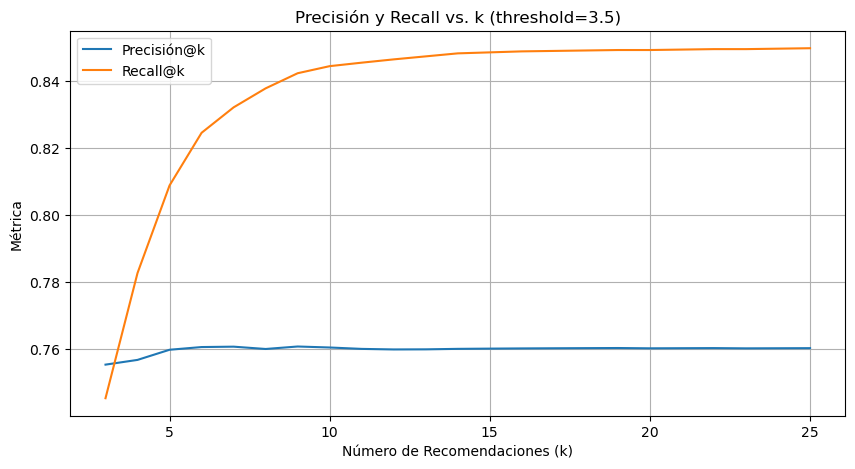

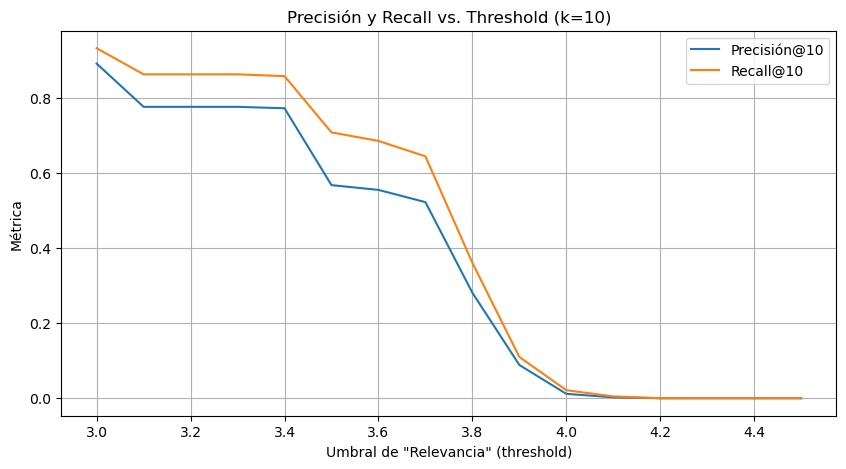

In [25]:
#Desarrolle su código aquí
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from surprise import Reader, Dataset, SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import mae



# Creando mapa de beerId -> beerName para mejor legibilidad
beerId_to_name = df_clean.drop_duplicates(subset=['beerId']).set_index('beerId')['beerName']

# Cargando en Surprise
reader = Reader(rating_scale=(1, 5))
df_surprise = df_clean[['userId', 'beerId', 'rating']]
data = Dataset.load_from_df(df_surprise, reader)

# Dividiendo en train/test
trainset, testset = train_test_split(data, test_size=0.30, random_state=42)

# Entrenando el MEJOR modelo (SVD)
print("Entrenando el mejor modelo (SVD)...")
model_svd = SVD(random_state=42)
model_svd.fit(trainset)

# Generando predicciones en el set de prueba (para tareas 3, 4, 5)
predictions_test = model_svd.test(testset)
print("Modelo listo.")
print("-" * 30)


print(" Top 3 Recomendaciones para Carl (userId=100) ")

#    Retornando las N mejores recomendaciones para cada usuario a partir de un conjunto de predicciones.
def get_top_n(predictions, n=10):
    #Mapeando predicciones a usuarios
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    #Ordenando y cortando las N mejores para cada usuario
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

# Generando predicciones para TODOS los items que NO están en el trainset
anti_testset = trainset.build_anti_testset()
all_predictions = model_svd.test(anti_testset)

# Obteniendo el diccionario de todas las top N
top_n_recs = get_top_n(all_predictions, n=3)

# Mostrando las 3 mejores para Carl (userId=100)
carls_recs_ids = top_n_recs.get(100, []) # Usamos .get para evitar error si no hay
if carls_recs_ids:
    print(f"Mejores 3 recomendaciones (IDs) para Carl: {carls_recs_ids}")

    # Mapeando a nombres para que sea legible
    carls_recs_named = [(beerId_to_name.get(iid, iid), est) for iid, est in carls_recs_ids]
    print("\nRecomendaciones (Nombres):")
    for cerveza, rating_est in carls_recs_named:
        print(f"  - {cerveza} (Rating predicho: {rating_est:.2f})")
else:
    print("No se pudieron generar recomendaciones para Carl (userId=100).")
print("-" * 30)

# Predecir 5 cervezas aleatorias para Carl

print(" 5 Predicciones aleatorias para Carl (userId=100) ")

#Encontrando cervezas que Carl NO ha calificado
beers_rated_by_carl = df_clean[df_clean['userId'] == 100]['beerId'].unique()
all_beers = df_clean['beerId'].unique()
beers_not_rated_by_carl = np.setdiff1d(all_beers, beers_rated_by_carl)

# Seleccionar 5 cervesas aleatorias
if len(beers_not_rated_by_carl) >= 5:
    random_beers_ids = np.random.choice(beers_not_rated_by_carl, 5, replace=False)

    print("Prediciendo ratings para 5 cervezas que Carl no ha probado:")
    for beer_id in random_beers_ids:
        # Usando el modelo SVD para predecir
        pred = model_svd.predict(uid=100, iid=beer_id)
        beer_name = beerId_to_name.get(beer_id, beer_id)
        print(f"  - {beer_name}: {pred.est:.2f} estrellas")
else:
    print("Carl ha calificado todas las cervezas o no hay suficientes para muestrear.")
print("-" * 30)

#  Precisión y Recall (k=10, threshold=3.5)

print(" Precisión y Recall @k=10, th=3.5")

precisions, recalls = precision_recall_at_k(predictions_test, k=10, threshold=3.5)

# Calculando el promedio
avg_precision = sum(precisions.values()) / len(precisions)
avg_recall = sum(recalls.values()) / len(recalls)

print(f"Promedio Precision@10: {avg_precision:.4f}")
print(f"Promedio Recall@10:    {avg_recall:.4f}")


#  Gráfico vs k

print(" Gráfico Precisión/Recall vs. k (3-25) ")
k_values = range(3, 26)
avg_precisions = []
avg_recalls = []

for k in k_values:
    prec, rec = precision_recall_at_k(predictions_test, k=k, threshold=3.5)
    avg_precisions.append(sum(prec.values()) / len(prec))
    avg_recalls.append(sum(rec.values()) / len(rec))

# Graficando
plt.figure(figsize=(10, 5))
plt.plot(k_values, avg_precisions, label='Precisión@k')
plt.plot(k_values, avg_recalls, label='Recall@k')
plt.title('Precisión y Recall vs. k (threshold=3.5)')
plt.xlabel('Número de Recomendaciones (k)')
plt.ylabel('Métrica')
plt.legend()
plt.grid(True)
plt.savefig('grafico_vs_k.png')
print("Gráfico 'grafico_vs_k.png' guardado.")


#Gráfico vs threshold

print("Tarea 5: Gráfico Precisión/Recall vs. threshold (3.0-4.5) ")
threshold_values = np.arange(3.0, 4.6, 0.1)
avg_precisions_thresh = []
avg_recalls_thresh = []

for thresh in threshold_values:
    prec, rec = precision_recall_at_k(predictions_test, k=10, threshold=thresh)
    avg_precisions_thresh.append(sum(prec.values()) / len(prec))
    avg_recalls_thresh.append(sum(rec.values()) / len(rec))

# Graficando
plt.figure(figsize=(10, 5))
plt.plot(threshold_values, avg_precisions_thresh, label='Precisión@10')
plt.plot(threshold_values, avg_recalls_thresh, label='Recall@10')
plt.title('Precisión y Recall vs. Threshold (k=10)')
plt.xlabel('Umbral de "Relevancia" (threshold)')
plt.ylabel('Métrica')
plt.legend()
plt.grid(True)
plt.savefig('grafico_vs_threshold.png')
print("Gráfico 'grafico_vs_threshold.png' guardado.")



# Estimando ratings faltantes (Matriz Densa)

print("Tarea 6: Generar Matriz Densa (Usuario-Producto)")


#    Convertir predicciones en un DataFrame.
df_preds = pd.DataFrame(
    [(pred.uid, pred.iid, pred.est) for pred in all_predictions],
    columns=['userId', 'beerId', 'rating']
)

# Combinando las calificaciones ORIGINALES con las PREDICHAS
df_full = pd.concat([df_surprise, df_preds])

#Eliminando duplicados, quedándonos con la calificación ORIGINAL
df_full = df_full.drop_duplicates(subset=['userId', 'beerId'], keep='first')

# Pivotando para crear la matriz densa
try:
    matriz_densa = df_full.pivot_table(
        index='userId',
        columns='beerId',
        values='rating'
    )

    print("Matriz densa generada. Primeras 5 filas/columnas:")
    print(matriz_densa.iloc[:5, :5].to_markdown(floatfmt=".2f"))

    # Verificar nulos (no debería haber, pero es buena práctica)
    # nulos = matriz_densa.isnull().sum().sum()
    # print(f"Nulos restantes: {nulos}")

except MemoryError:
    print("Error de Memoria: La matriz densa (706x3747) es demasiado grande para pivotar en memoria.")
except Exception as e:
    print(f"Se produjo un error al pivotar: {e}")


El modelo elegido SVD entrega para Carl un top 3 de cervezas con ratings predichos sobre 4, por lo que las recomendaciones son coherentes con un usuario exigente. Además las 5 cervezas no probadas que se evaluaron al azar también tienen notas esperadas cercanas a 4, lo que muestra que el sistema tiende a recomendar cervezas de buena calidad según el modelo.

Para evaluar el rendimiento global, la precisión y el recall promedios con k = 10 y threshold = 3.5 son aproximadamente 0.76 y 0.84. Lo que implica que el modelo recupera la mayoría de las cervezas relevantes y que una parte importante de lo recomendado sí resulta ser relevante.

Al variar k entre 3 y 25, la precisión se mantiene casi estable mientras que el recall sube y luego se estabiliza. Esto muestra que aumentar k permite cubrir más cervezas relevantes, pero no mejora mucho la calidad promedio de cada recomendación. Un valor intermedio como k = 10 es razonable.

Al variar el threshold entre 3.0 y 4.5, tanto precisión como recall caen rápido a medida que el umbral se vuelve más exigente. Esto significa que el modelo distingue bien entre cervezas aceptables y malas, pero le cuesta identificar solo las excepcionales, ya que son menos y hay poca información para separarlas.

Al completar la matriz usuario–producto con todas las predicciones del modelo se obtiene una matriz densa sin valores nulos, lo que permite recomendar cualquier cerveza a cualquier usuario, aunque siempre con las limitaciones propias del comportamiento medido en las métricas anteriores.

# Conclusión

Éxito!
<center>
<img src ="https://i.gifer.com/origin/cb/cbd80e6045652ab123caffef72f29210_w200.gif" width = 400 />
